### Deep Learning

In [4]:
import keras

##### Introduction to Artificial Neural Networks with Keras

In [9]:
#Perceptron using sklearn 

import numpy as np

from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron 


iris = load_iris()
X = iris.data[:, (2, 3)]
y = (iris.target == 0).astype(int)

per_clf = Perceptron()
per_clf.fit(X,y)


y_pred = per_clf.predict([[2,0.5]])
print(y_pred)

[0]


##### Tensorflow installation

In [10]:
import tensorflow as tf  
from tensorflow import keras 
print(tf.__version__)

print(keras.__version__)

2.21.0
3.14.0


### Building an Image Classifier Using the sequential API

In [11]:
fashion_mnist = keras.datasets.fashion_mnist

(X_train_full ,y_train_full) , (X_test , y_test ) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [12]:
print(X_train_full.shape )

print(X_train_full.dtype )

(60000, 28, 28)
uint8


In [13]:
X_valid , X_train = X_train_full[:5000] / 255.0 , X_train_full[5000 : ] / 255.0 
y_valid ,y_train = y_train_full[:5000] , y_train_full[5000 :]


In [14]:
#List of class names for the dataset

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat' , 'Sandal' ,'Shirt' ,'Sneaker' , 'Bag' , 'Ankle boot']

class_names[y_train[0]]

'Coat'

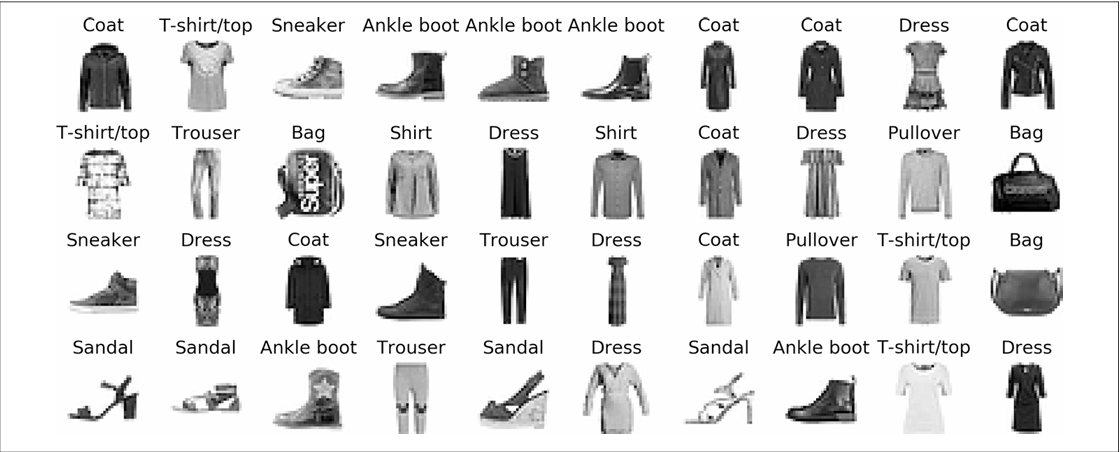

In [ ]:
#CREATING THE MODEL USING SEQUENTIAL API


model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300 , activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))


#improve implementation using functional API

model = keras.models.Sequential([
    keras.layers.Flatten(input_sahpe=[28,28]),
    keras.layers.Dense(300 ,activation ='relu'),
    keras.layers.Dense(100,activation = 'relu'),
    keras.layers.Dense(10,activation='softmax')

])





c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [20]:
hidden1 = model.layers[1]
print(hidden1.name)
print(model.get_layer('dense') is hidden1)

dense
True


In [21]:
weights , bias = hidden1.get_weights()
print(weights)
print(weights.shape)
print(bias)
print(bias.shape)

[[ 0.03305524 -0.06800737 -0.00308775 ... -0.0096323  -0.06531826
  -0.00576267]
 [-0.00168871 -0.07407645  0.00842766 ...  0.03989291  0.03252088
  -0.03267836]
 [ 0.03602447 -0.01092958  0.035992   ... -0.02002494 -0.04624906
   0.03110203]
 ...
 [ 0.0109361   0.02844827 -0.05384145 ...  0.00680481 -0.01624839
   0.03936652]
 [ 0.01471481 -0.01739857  0.04127528 ...  0.00030892  0.04341701
   0.0372653 ]
 [-0.04855347  0.0122266   0.00817358 ... -0.05167855 -0.00533386
  -0.0491075 ]]
(784, 300)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [ ]:
#compiling the model 

model.compile(loss = "sparse_categorical_crossentropy",
              optimizer = 'sgd',
                metrics = ['accuracy'])

##### Training and evaluating the model

In [23]:
history = model.fit(X_train , y_train ,epochs = 30 , validation_data=(X_valid , y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7682 - loss: 0.7115 - val_accuracy: 0.8322 - val_loss: 0.5022
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8309 - loss: 0.4870 - val_accuracy: 0.8480 - val_loss: 0.4502
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8463 - loss: 0.4428 - val_accuracy: 0.8638 - val_loss: 0.4132
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8548 - loss: 0.4148 - val_accuracy: 0.8606 - val_loss: 0.4059
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8632 - loss: 0.3947 - val_accuracy: 0.8464 - val_loss: 0.4164
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8677 - loss: 0.3793 - val_accuracy: 0.8740 - val_loss: 0.3660
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8712 - loss: 0.3655 - val_accuracy: 0.8690 - val_loss: 0.3746
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8762 - loss: 0.3539 - 

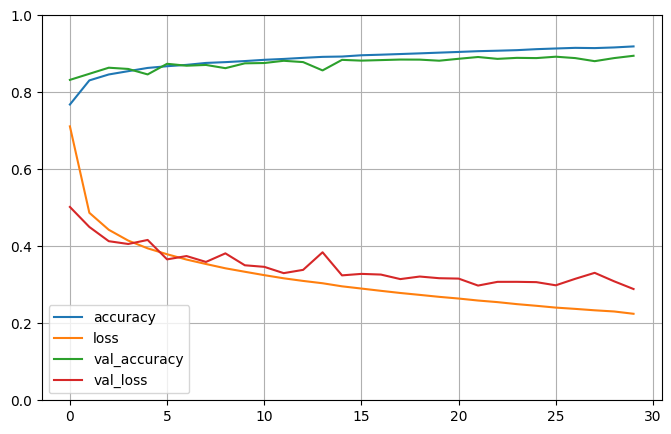

In [25]:
#visualization 

import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [26]:
model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8528 - loss: 63.0602


[63.06022644042969, 0.8528000116348267]

In [28]:
#make predictions 

X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [30]:
# ...existing code...
y_pred = np.argmax(model.predict(X_new), axis=-1)
y_pred
# ...existing code...
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([9, 2, 1])

In [31]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [32]:
y_new  = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

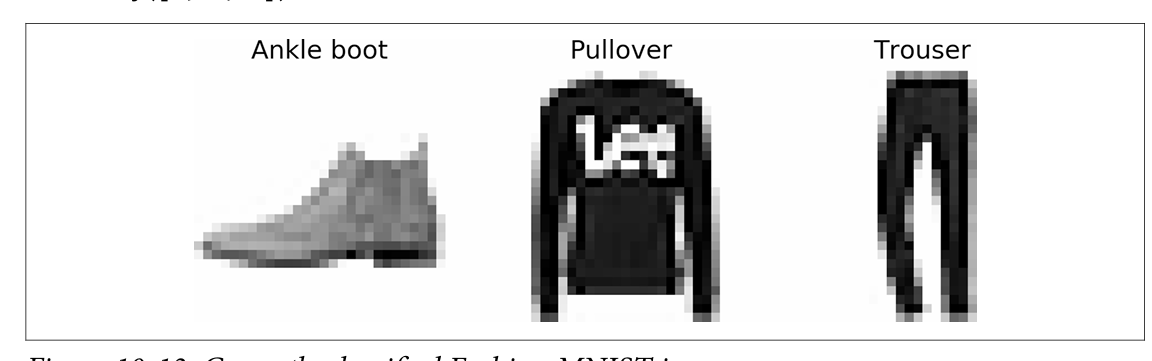

### Building a Regression MLP Using the sequantial API

In [ ]:
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()


X_train_full , X_test , y_train_full , y_test = train_test_split(housing.data , housing.target)

X_train , X_valid , y_train , y_valid = train_test_split(X_train_full , y_train_full)   

#standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)   

In [34]:
model = keras.models.Sequential ([
      keras.layers.Dense(30 , activation = 'relu' , input_shape = X_train.shape[1:]),
      keras.layers.Dense(1)
])

model.compile(loss = 'mean_squared_error' , optimizer = 'sgd')
history = model.fit(X_train , y_train , epochs = 20 , validation_data=(X_valid , y_valid))
mse_test = model.evaluate(X_test , y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)
y_pred

Epoch 1/20


c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8.4154 - val_loss: 8.2515
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2944 - val_loss: 8.2908
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2822 - val_loss: 8.2450
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8.2723 - val_loss: 8.2332
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2757 - val_loss: 8.2431
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2748 - val_loss: 8.2496
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2722 - val_loss: 8.2304
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2715 - val_loss: 8.2280
Epoch 9/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2694 - val_loss: 8.2367
Epoch 10/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2681 - val_loss: 8.2292
Epoch 11/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2635 - val_loss: 8.2275
Epoch 12/20
1719/1719 ━━━━━━━━━━━━━━━━━━━

array([[[  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  2.823285 ],
        [ -4.59292  ],
        [ -2.7600436],
        [ 50.84081  ],
        [ 47.975418 ],
        [ 54.980682 ],
        [ 54.24697  ],
        [ 52.641426 ],
        [ 48.455284 ],
        [ 54.54206  ],
        [ 47.978706 ],
        [ 48.905792 ],
        [ 62.645714 ],
        [ 73.95909  ],
        [ 79.19494  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ],
        [  4.66383  ]],

       [[ -2.0920577],
        [ 38.5419   ],
        [ 60.744545 ],
        [ 54.99793  ],
        [ 54.59177  ],
        [ 65.86044  ],
        [ 31.296257 ],
        [ 68.74665  ],
        [ 65.13591  ],
        [ 74.72513  ],
        [ 72.10847  ],
        [ 76.63232  ],
        [ 69.72297  ],
        [ 70.07311  ],
        [ 69.03867  ],
        [

In [35]:
model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1519.8124


1519.8123779296875

#### Building Complex Models Using the functional API

In [ ]:

# Wide Deep Neural Network

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30 , activation='relu')(input_)
hidden2 = keras.layers.Dense(30 , activation ='relu')(hidden1)
concat = keras.layers.Concatenate()(input_ ,  hidden2)
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])


![Screenshot 2026-04-29 131111.png](<attachment:Screenshot 2026-04-29 131111.png>)
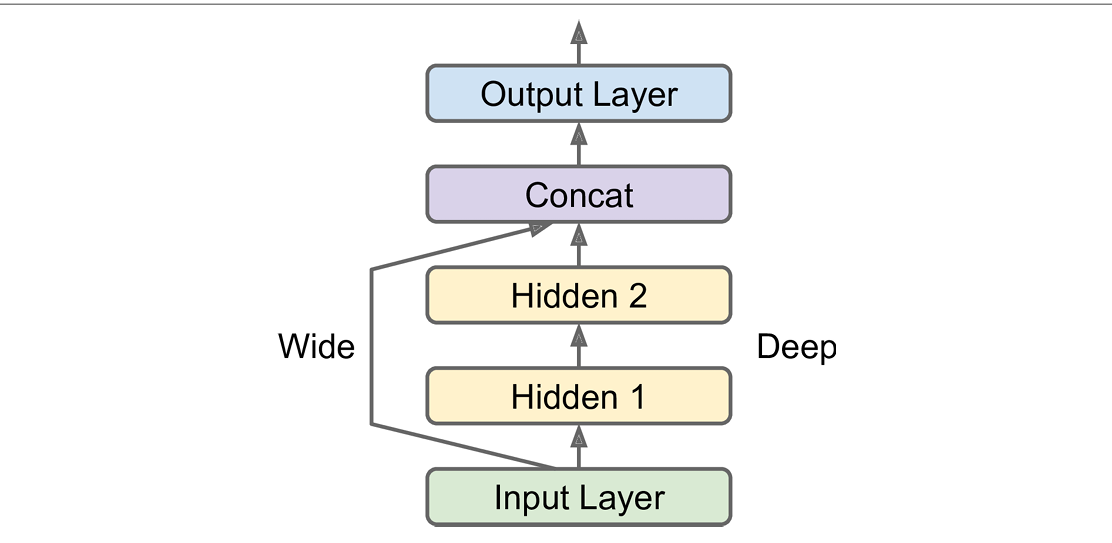

In [ ]:
#handlidng multiple inputs and outputs  

input_A = keras.layers.Input(shape=[5] , name="wide_input")
input_B =keras.layers.Input(shape=[6], name ='deep_input')
hidden1 = keras.layers.Dense(30 , activation='relu')(input_B)
hidden2 =  keras.layers.Dense(30,activation ='relu')(hidden1)
concat =keras.layers.concatenate([input_A , hidden2])
output = keras.layers.Dense(1, name ='output')(concat)
model = keras.Model(inputs=[input_A,input_B] , outputs =[output])

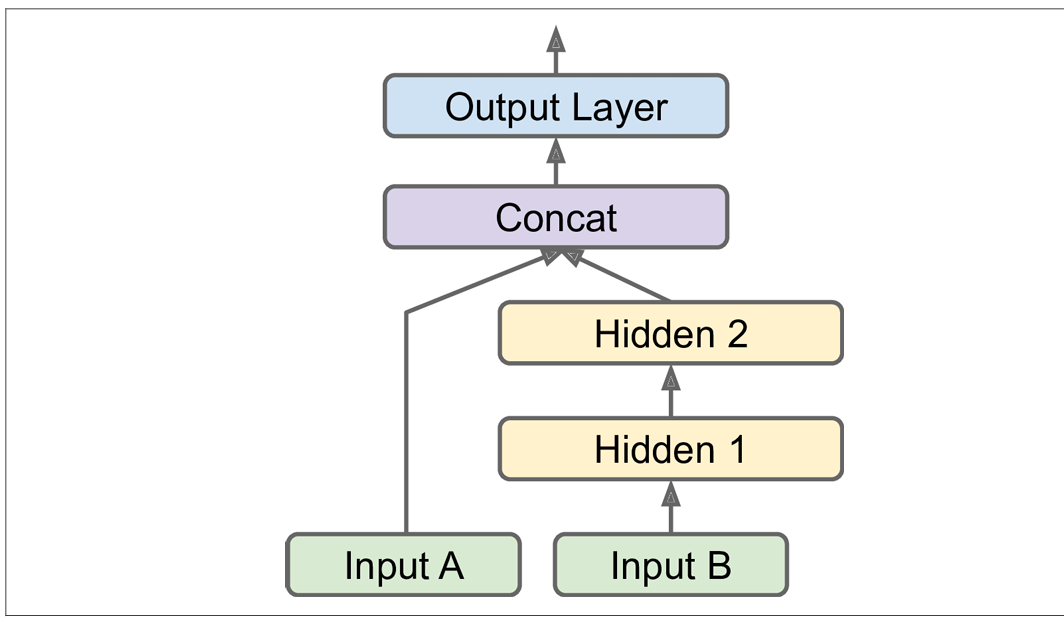

In [ ]:
#fit model

model.compile(loss='mse' , optimizer  = keras.optimizers.SGD(lr=1e-3))

X_train_A , X_train_B = X_train[:, :5] ,X_train[:, 2 :]
X_valid_A ,X_valid_B = X_valid[:, :5] ,X_valid[:,2:]

X_test_A , X_test_B = X_test[:, :5] ,X_test[:, 2:]
X_new_A , X_new_B = X_test_A[:3] ,X_test_B[:3]

history = model.fit((X_train_A , X_train_B) , y_train , epochs = 20 , validation_data = ((X_valid_A , X_valid_B) , y_valid))
mse_test = model.evaluate((X_test_A , X_test_B) , y_test)   
y_pred = model.predict((X_new_A , X_new_B))

In [ ]:
#wide and deep model with multiple outputs


input_A = keras.layers.Input(shape=[5] , name="wide_input")
input_B =keras.layers.Input(shape=[6], name ='deep_input')
hidden1 = keras.layers.Dense(30 , activation='relu')(input_B)
hidden2 =  keras.layers.Dense(30,activation ='relu')(hidden1)
concat =keras.layers.concatenate([input_A , hidden2])
output = keras.layers.Dense(1, name ='main_output')(concat)
aux_output = keras.layers.Dense(1 ,name='aux_output')(hidden2)
model = keras.Model(inputs=[input_A , input_B] , outputs=[output , aux_output])


In [ ]:
model.compile(loss=['mse','mse']) , loss_weights=[0.9,0.1] , optimizer ='sgd')

history = model.fit((X_train_A , X_train_B) , (y_train , y_train) , epochs = 20 , validation_data = ((X_valid_A , X_valid_B) , (y_valid , y_valid)))

In [ ]:
#when we evaluate the model ,Keras will return the total loss ,as well the individual losses :

total_loss , main_loss ,aux_loss = model.evaluate((X_test_A , X_test_B) , (y_test , y_test))

In [ ]:
#similarly ,the predict() method will return prediction for each output
y_pred_main , y_pred_aux = model.predict((X_new_A , X_new_B))

### Saving and Restoring a Model

In [ ]:
model = keras.models.Sequantial([
    keras.layers.Dense(30 , activation='relu' , input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)   
])
model.compile(loss = 'mean_squared_error' , optimizer = 'sgd')
history = model.fit(X_train , y_train , epochs = 20 , validation_data=(X_valid , y_valid))
model.save("my_keras_model.h5")

In [ ]:
#Loading the model
model = keras.models.load_model("my_keras_model.h5")

### Using Callbacks


In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5" , save_best_only=True)
history = model.fit(X_train , y_train , epochs = 20 , validation_data=(X_valid , y_valid) 
                    , callbacks=[checkpoint_cb])      


In [ ]:
#implementing early stopping
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5" , save_best_only=True)
history = model.fit(X_train , y_train , epochs = 20 , validation_data=(X_valid , y_valid) 
                    , callbacks=[early_stopping_cb, checkpoint_cb])
model = keras.models.load_model("my_keras_model.h5")

In [ ]:
#Early Stopping 

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

history= model.fit(X_train , y_train , epochs = 20 , validation_data=(X_valid , y_valid) 
                   , callbacks=[checkpoint_cb, early_stopping_cb] )

In [ ]:
#ReduceROnPlateau - reduces the learning rate when a metric has stopped improving. It monitors a quantity and if no improvement is seen for a 'patience' number of epochs, it reduces the learning rate by a factor of 'factor'. This can help the model to converge to a better solution when it gets stuck in a plateau.  


reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor ='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.001
)

#Normally patience is more less than early stopping patience because you want to reduce
#  the learning rate before stopping the training.

In [ ]:
#TensorBoard - is a visualization tool provided by TensorFlow that allows you to visualize various aspects of your model's training process, such as the loss and accuracy curves, histograms of weights and biases, and even the computational graph of the model. It can be used to monitor the training process in real-time and to compare different runs of the model. To use TensorBoard, you need to create a callback that writes logs to a specified directory during training, and then you can launch TensorBoard to visualize those logs.   
import os
from utils.run_lodgir import get_run_logdir

root_logdir = os.path.join(os.curdir , "my_logs")
run_logdir = get_run_logdir(root_logdir)


tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir=run_logdir,
    histogram_freq=1,
    profile_batch='10,15'
)    


In [ ]:
# CSVLogger
csv_logger_cb = keras.callbacks.CSVLogger("my_keras_logs.csv", separator=',', append=True)

In [ ]:
# AlertaBackendCallback - is a custom callback that sends an alert to a backend service
#  when a certain condition is met during training. For example, you can create a callback that sends an alert if the
#  loss exceeds a certain threshold, indicating that the model is diverging. This can be useful for monitoring long
#  training runs and taking action if something goes wrong. You would need to implement the logic for sending the alert
#  in the callback's methods, 
#  such as on_epoch_end or on_batch_end.
from callbacks import AlertaBackendCallback
mi_callback_personalizado = AlertaBackendCallback()


In [ ]:

history = model.fit(
  X_train , y_train , epochs = 20 , validation_data=(X_valid , y_valid),
  callbacks=[
      checkpoint_cb,
      reduce_lr_cb,
      tensorboard_cb,
      early_stopping_cb,
      csv_logger_cb,
      mi_callback_personalizado

  ])


In [ ]:
#notification callback

from callbacks.BackendNotifierCallback import BackendNotifierCallback

backend_notifier_cb = BackendNotifierCallback()

In [ ]:
# Wide and Deep Multiple

input_A =keras.layers.Input(shape=[5],name='wide_input')
input_B =keras.layers.Input(shape=[6] ,name='deep_input')

hidden1= keras.layers.Dense(30,activation='relu')(input_B)
hidden2= keras.layers.Dense(30,activation='relu')(hidden1)

concat = keras.layers.concatenate([input_A , hidden2])


output = keras.layers.Dense(1 ,name='main|_output')(concat)
aux_output = keras.layers.Dense(1 , name='aux_output')(hidden2)

model = keras.Model(inputs=[input_A , input_B] , outputs=[output , aux_output])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=["mse", "mse"],
    loss_weights=[0.9, 0.1] # El jefe manda (90%), el auditor asiste (10%)
)


print("Iniciando secuencia principal...")


history = model.fit(
    x=[X_train_A, X_train_B], 
    y=[y_train, y_train],     
    epochs=500,              
    validation_data=([X_valid_A, X_valid_B], [y_valid, y_valid]),
    callbacks=[
        backend_notifier_cb, 
        reduce_lr_cb, 
        early_stopping_cb, 
        checkpoint_cb, 
        tensorboard_cb, 
        csv_logger_cb
    ]
)


## Tensor Board

In [ ]:
#%load_ext tensorboard
#%tensorboard --logdir=./my_logs --port=6006

In [ ]:
#tf.summary 
#this writer as a context to log scalars, histograms, images, audio, and text,
#all of which can then be visualized using TensorBoard
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)
with writer.as_default():
    for step in range(1, 1000 + 1):
     tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
     data = (np.random.randn(100) + 2) * step / 100 # some random data
     tf.summary.histogram("my_hist", data, buckets=50, step=step)
     images = np.random.rand(2, 32, 32, 3) # random 32×32 RGB images
     tf.summary.image("my_images", images * step / 1000, step=step)
     texts = ["The step is " + str(step), "Its square is " + str(step**2)]
     tf.summary.text("my_text", texts, step=step)
     sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
     audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
     tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)


### Fine -Tuning Neural Network Hyperparameters



In [ ]:
#Create a simple Sequential model for univariate regression
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(lr=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)
keras_reg.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb, reduce_lr_cb, early_stopping_cb, tensorboard_cb, csv_logger_cb, mi_callback_personalizado])
mse_test = keras_reg.score(X_test, y_test)
y_pred = keras_reg.predict(X_new)



In [ ]:
#use a RandomizedSearchCV to find the best hyperparameters for the model


from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_ditribs = {
    "n_hidden": [0, 1, 2, 3],   
    "n_neurons": np.arange(1, 100),
    "learning_rate": reciprocal(3e-4, 3e-2),
}

rnd_search_cv = RandomizedSearchCV(keras_reg, param_distributions=param_ditribs, n_iter=10, cv=3)
rnd_search_cv.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb, reduce_lr_cb, early_stopping_cb, tensorboard_cb, csv_logger_cb, mi_callback_personalizado])   

In [ ]:
rnd_search_cv.best_params_
rnd_search_cv.best_score_
rnd_search_cv.best_estimator_.model

## Transfer Learning

In [ ]:
from dataclasses import dataclass
from typing import Tuple, List
import tensorflow as tf
from tensorflow import keras
import numpy as np

@dataclass
class TransferConfig:
    image_size: Tuple[int, int] = (224, 224)
    batch_size: int = 64
    epochs_head: int = 10
    epochs_finetune: int = 10
    base_learning_rate: float = 1e-3
    fine_tune_learning_rate: float = 1e-4
    fine_tune_at: int = 100  # if lower than number of layers, those above will be trainable
    model_dir: str = "transfer_models"
    run_logdir: str = "./transfer_logs"

cfg = TransferConfig()

def _preprocess(image, label, image_size=cfg.image_size):
    # accept numpy arrays from notebook (grayscale 28x28 or floats 0-1)
    image = tf.cast(image, tf.float32)
    if image.shape.rank == 2:
        image = tf.expand_dims(image, -1)
    # scale to [0,1] if coming as uint8
    if image.dtype == tf.uint8:
        image = image / 255.0
    # convert to 3 channels
    image = tf.image.grayscale_to_rgb(image) if image.shape[-1] == 1 else image
    image = tf.image.resize(image, image_size)
    return image, label

def make_dataset(X: "np.ndarray", y: "np.ndarray", training: bool = True) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(10000)
    ds = ds.map(lambda im, lb: _preprocess(im, lb), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(cfg.batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_transfer_model(num_classes: int, input_shape: Tuple[int,int,3]=(224,224,3)) -> keras.Model:
    base = keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    return model, base

def get_callbacks():
    cb = []
    cb.append(keras.callbacks.ModelCheckpoint(cfg.model_dir + "/best.h5", save_best_only=True))
    cb.append(keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True))
    cb.append(keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6))
    cb.append(keras.callbacks.TensorBoard(cfg.run_logdir))
    return cb

def compile_and_train(model: keras.Model, train_ds, val_ds, epochs: int, lr: float):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=get_callbacks())
    return history

def fine_tune(model: keras.Model, base: keras.Model, train_ds, val_ds, epochs: int, lr: float, fine_tune_at: int):
    # Unfreeze from fine_tune_at
    base.trainable = True
    for layer in base.layers[:fine_tune_at]:
        layer.trainable = False
    return compile_and_train(model, train_ds, val_ds, epochs, lr)

# --- Pipeline execution (uses X_train, X_valid, X_test, y_train, y_valid, y_test, class_names from notebook) ---

num_classes = len(class_names)
train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_valid, y_valid, training=False)
test_ds = make_dataset(X_test, y_test, training=False)

model, base = build_transfer_model(num_classes=num_classes, input_shape=(*cfg.image_size, 3))

# Train head
compile_and_train(model, train_ds, val_ds, cfg.epochs_head, cfg.base_learning_rate)

# Fine-tune
fine_tune(model, base, train_ds, val_ds, cfg.epochs_finetune, cfg.fine_tune_learning_rate, cfg.fine_tune_at)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}  Test acc: {test_acc:.4f}")

# Quick prediction example
X_sample = X_test[:9]
y_sample = y_test[:9]
probs = model.predict(make_dataset(X_sample, y_sample, training=False))
preds = np.argmax(probs, axis=-1)
print("Pred:", [class_names[p] for p in preds])
print("True:", [class_names[int(t)] for t in y_sample])

# Save final model (SavedModel format)
model.save(cfg.model_dir + "/final_transfer_model")

#### Find the best Hyperparameters

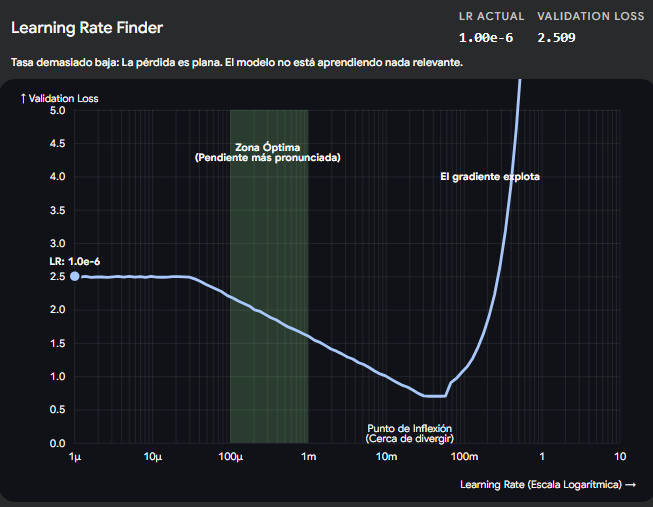

When you already have a good base Learning Rate but want to squeeze the most out of the model for production, we discard GridSearch and use Bayesian Optimization Libraries such as KerasTuner or Optuna.

### The Vanishing / Exploding Gradients Problems

Glorot and He Initialization

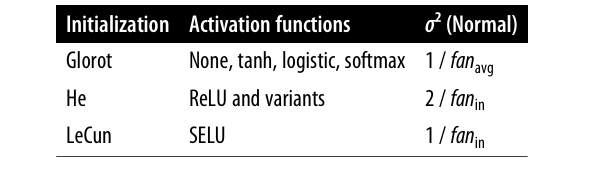

In [ ]:
keras.layers.Dense(10,activation='relu' ,kernel_initializer='he_normal')


In [ ]:
he_avg_init = keras.initializers.VarianceScaling(scale=2.0, mode='fan_avg', distribution='uniform')

keras.layers.Dense(10, activation='relu', kernel_initializer=he_avg_init)

### Saturating Activation  Fuctions

In [ ]:
# Examples of saturating activation functions

sigmoid_layer = keras.layers.Dense(1, activation="sigmoid")
tanh_layer = keras.layers.Dense(1, activation="tanh")
softsign_layer = keras.layers.Dense(1, activation="softsign")

print("Sigmoid layer:", sigmoid_layer)
print("Tanh layer:", tanh_layer)
print("Softsign layer:", softsign_layer)

# Saturation demo: large |x| values push outputs near limits
x = tf.constant([[-10.0], [-2.0], [0.0], [2.0], [10.0]])

print("\nActivation outputs")
print("sigmoid:", tf.squeeze(tf.nn.sigmoid(x)).numpy())
print("tanh   :", tf.squeeze(tf.nn.tanh(x)).numpy())
print("softsign:", tf.squeeze(tf.nn.softsign(x)).numpy())

# Gradient demo: gradients become very small in saturated regions
def activation_gradients(fn, x_values):
    x_var = tf.Variable(x_values, dtype=tf.float32)
    with tf.GradientTape() as tape:
        y = fn(x_var)
    grads = tape.gradient(y, x_var)
    return tf.squeeze(grads).numpy()

print("\nActivation gradients")
print("sigmoid':", activation_gradients(tf.nn.sigmoid, x))
print("tanh'   :", activation_gradients(tf.nn.tanh, x))
print("softsign':", activation_gradients(tf.nn.softsign, x))

###  Nonsaturating Activation Functions
    

In [2]:
# Examples of nonsaturating activation functions
import keras
relu_layer = keras.layers.Dense(10, activation="relu")
leaky_relu_layer = keras.layers.Dense(10, activation=keras.layers.LeakyReLU(alpha=0.01))
elu_layer = keras.layers.Dense(10, activation="elu")

print("ReLU:", relu_layer)
print("Leaky ReLU:", leaky_relu_layer)
print("ELU:", elu_layer)

ReLU: <Dense name=dense, built=False>
Leaky ReLU: <Dense name=dense_1, built=False>
ELU: <Dense name=dense_2, built=False>


c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


### Batch Normalization

In [ ]:
#implemeting batch normalization 
model = keras.models.Sequential([
     keras.layers.Flatten(input_shape=[28,28]),
     keras.layers.BatchNormalization(),
     keras.layers.Dense(300 ,activation='elu', kernel_initializer='he_normal');
     keras.layers BatchNormalization(),
     keras.layers.Dense(100, activation='elu', kernel_initializer='he_normal');
     keras.layers.BatchNormalization(),
     keras.layers.Dense(10, activation='softmax')


])

### Transfer Learning with Keras

In [ ]:
model_A = keras.model.load_model("my_keras_model.h5")
model_B_on_A = keras.models.Sequential(model_A.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1,activation='sigmoid'))



In [ ]:
model_A_clone = keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [ ]:

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss='binary_crossentropy', optimizer=keras.optimizers.SGD(lr=1e-3), metrics=['accuracy'])    

In [ ]:
history = model_B_on_A.fit(X_train_B,y_train_B,epochs=4
                           ,validation_data=(X_valid_B , y_valid_B))
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = keras.optimizer.SGD(lr=1e -4)
model_B_on_A.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model_B_on_A.fit(X_train_B,y_train_B,epochs=16
                           ,validation_data=(X_valid_B , y_valid_B))   

In [ ]:
model_B_on_A.evaluate(X_test_B , y_test_B)

### Momentum optimization

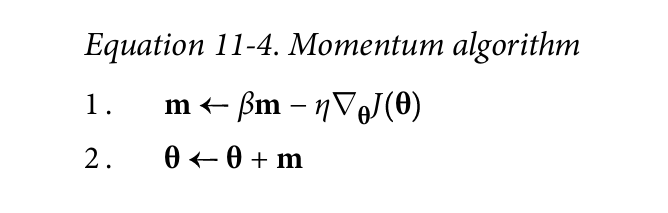

In [ ]:
## Momentum optimizer
optimizer = keras.optimizer.SGD(lr=0.001,momentum=0.9)

### Nesterov Accelerated Gradient

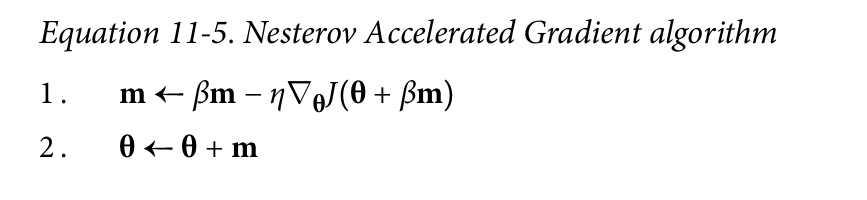

In [ ]:
optimizer = keras.optimizers.SGD(lr=0.001, momentum =0.9 ,nesterov =True)

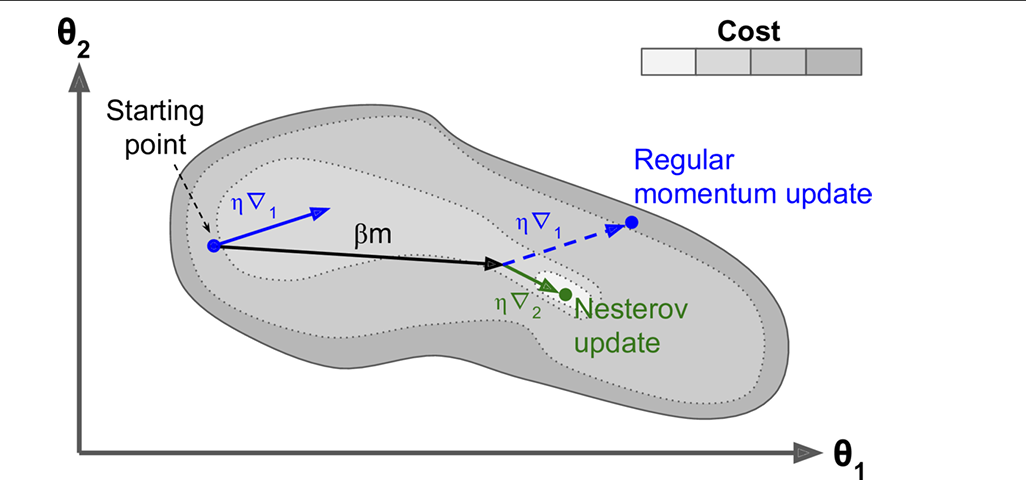

### AdaGrad

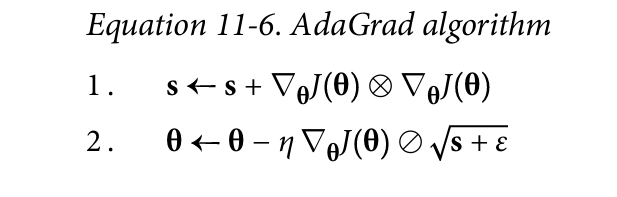

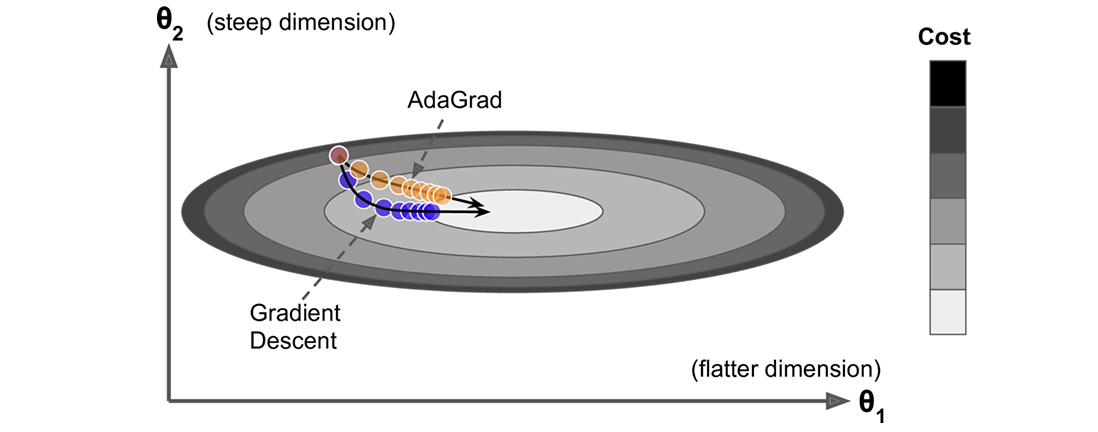

 you should not use it to train deep neu
ral networks (it may be efficient for simpler tasks such as Linear Regression, though).
Still, understanding AdaGrad is helpful to grasp the other adaptive learning rate
optimizers


### RMSProp

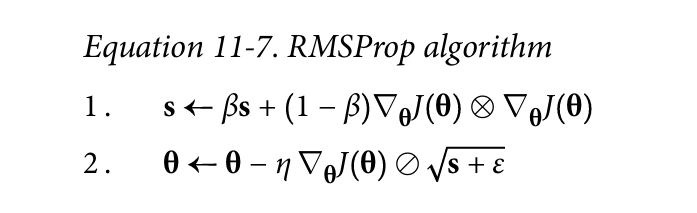

### Adam Optimizer

In [13]:
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)


In [ ]:
#exists two variants of Adam 
# 1. Adam (default)
Adam = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
# 2. Adamax (variant based on the infinity norm)    
Adamax = keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

# 3. AdamW (variant with decoupled weight decay)
AdamW = keras.optimizers.AdamW(learning_rate=0.001, beta_1=0.9, beta_2=0.999, weight_decay=1e-4)

![Screenshot 2026-04-30 171905.png](<attachment:Screenshot 2026-04-30 171905.png>)
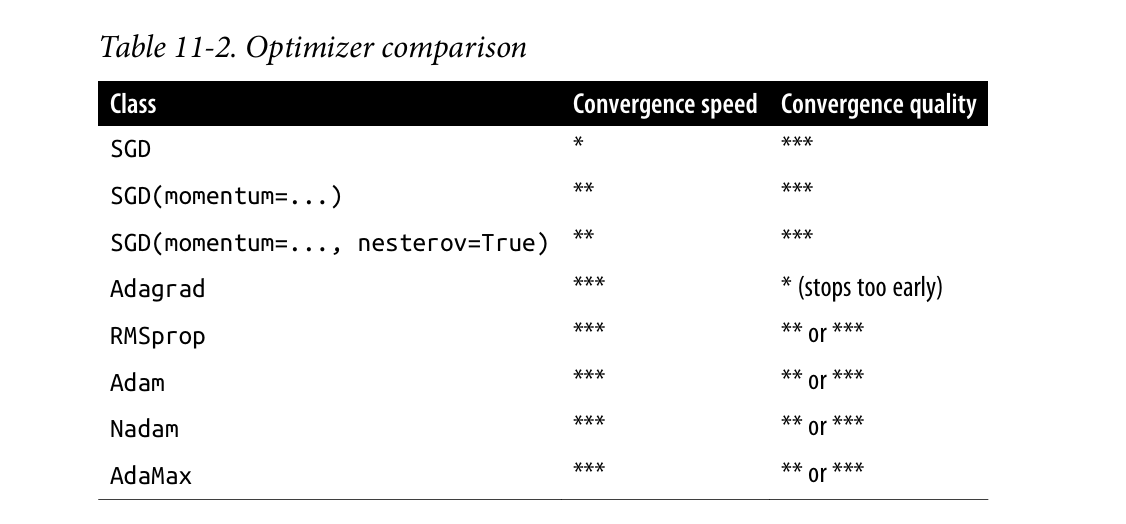

#### Implementing Learning schedules



In [ ]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, decay=1e-4)


#Implementing exponential decay learning rate schedule
def exponential_decay_fn(epoch):
   return 0.01 * 0.1**(epoch / 20)


#or

def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1**(epoch / s)
    return exponential_decay_fn
exponential_decay_fn = exponential_decay(lr0=0.01, s=20)
lr_scheduler_cb = exponential_decay(lr0=0.01, s=20)
lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[lr_scheduler])



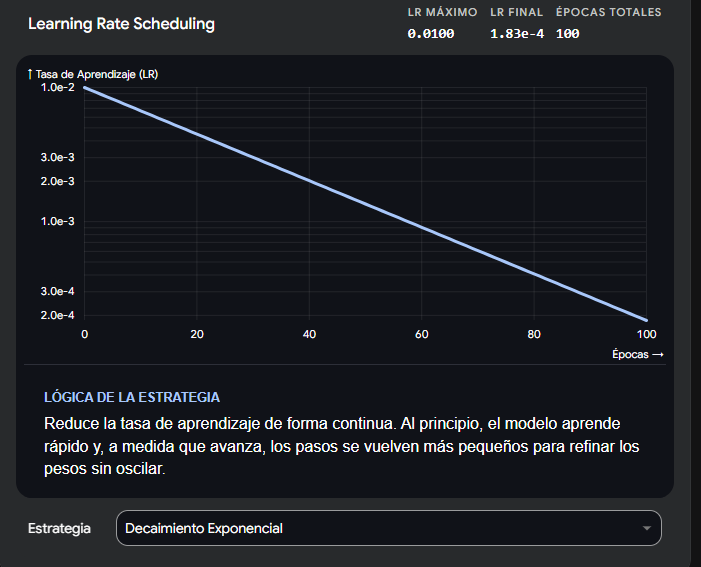

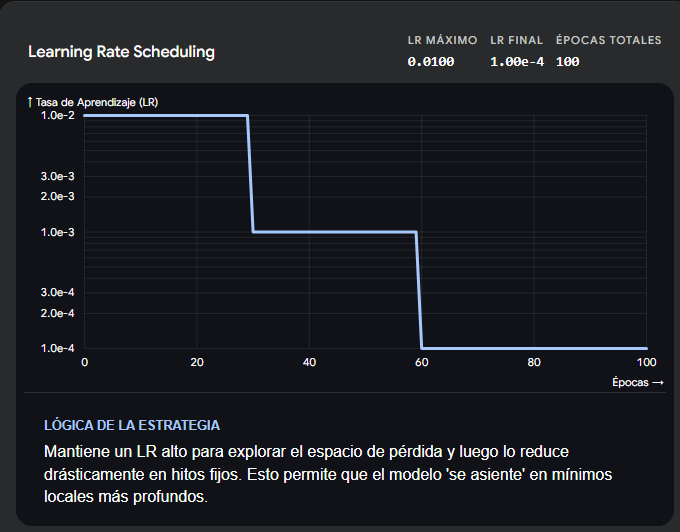

In [ ]:
#implmenting 1cycle learning rate schedule
initial_learning_rate = 0.01
lr_schedule = keras.experimental.CosineDecayRestarts(
    initial_learning_rate=initial_learning_rate,
    first_decay_steps=1000,
    t_mul=2.0,
    m_mul=1.0,
    alpha=0.0
)


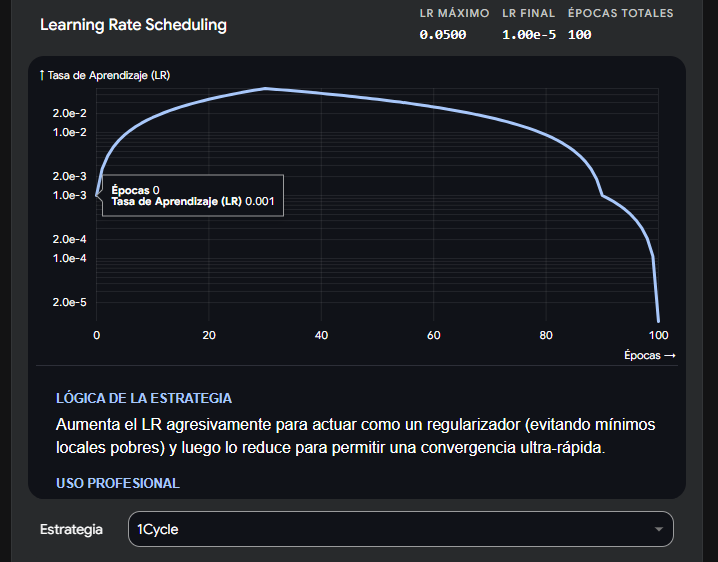

In [ ]:
reduce_lr_on_plateau_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_valid, y_valid),
    callbacks=[reduce_lr_on_plateau_cb]
)

### L1 and L2 regularization

In [ ]:
layer = keras.layers.Dense(10, activation='relu', kernel_initializer='he_normal',kernel_regularizer=keras.regularizers.l2(0.01))

In [15]:
from functools import partial

RegularizedDense = partial(
    keras.layers.Dense,
    activation="elu",
    kernel_initializer="he_normal",
    kernel_regularizer=keras.regularizers.l2(0.01),
)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    RegularizedDense(300),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax", kernel_initializer="glorot_uniform"),
])


c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Dropout

In [ ]:
model = keras.models.Sequential([
keras.layers.Flatten(input_shape=[28, 28]),
keras.layers.Dropout(rate=0.2),
keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dropout(rate=0.2),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dropout(rate=0.2),
keras.layers.Dense(10, activation="softmax")
])

### Monte Carlo Dropout
use when the model isnt sure about the prediction and you want to add some noise to the output to help it generalize better. It randomly sets a fraction of the input units to 0 at each update during training time, which helps prevent overfitting.

In [ ]:
import numpy as np

# Hacemos 100 predicciones con la misma entrada X_nueva, pero forzando training=True
predicciones_mc = [model(X_nueva, training=True) for _ in range(100)]

# Juntamos las 100 predicciones y calculamos el promedio y la varianza
promedio = np.mean(predicciones_mc, axis=0)
incertidumbre = np.std(predicciones_mc, axis=0) # Si esto es alto, el modelo duda

### Max Norm 
dropout recommended use Max Norm with he

In [ ]:
from tensorflow import keras

# Aplicamos un tope estricto de 1.0 al tamaño de los pesos de esta capa
keras.layers.Dense(100, activation="elu", 
                   kernel_initializer="he_normal",
                   kernel_constraint=keras.constraints.max_norm(1.0))

In [ ]:
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal",
kernel_constraint=keras.constraints.max_norm(1.))

### Practical Guidelines

Default DNN configuration

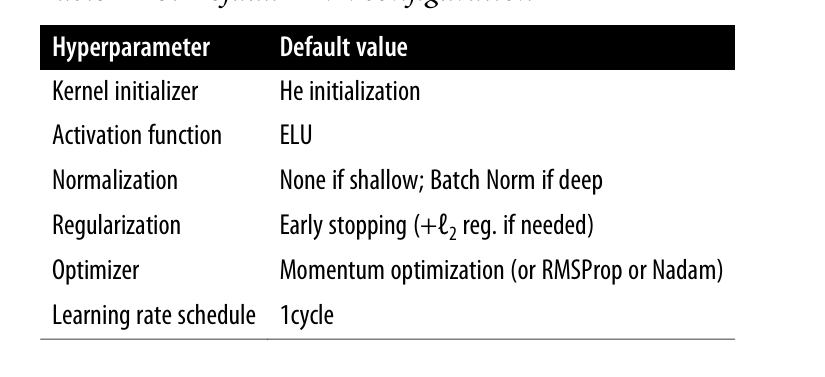

DNN configuration for a self normalizing net

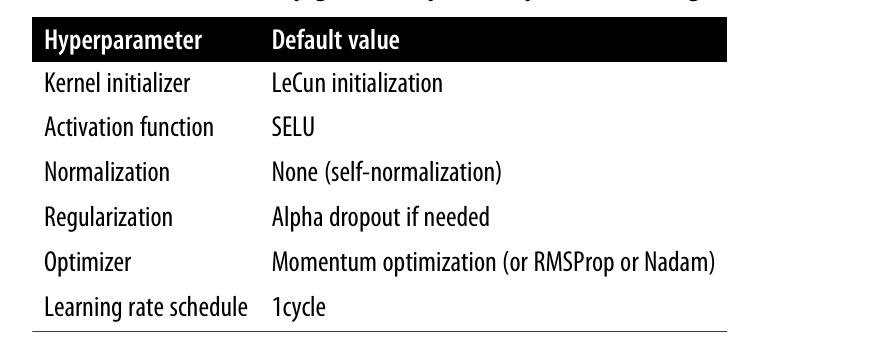

While the previous guidelines should cover most cases, here are some exceptions:
• If you need a sparse model, you can use ℓ1
 regularization (and optionally zero out
the tiny weights after training). If you need an even sparser model, you can use
the TensorFlow Model Optimization Toolkit. This will break self-normalization,
so you should use the default configuration in this case.
• If you need a low-latency model (one that performs lightning-fast predictions),
you may need to use fewer layers, fold the Batch Normalization layers into the
previous layers, and possibly use a faster activation function such as leaky ReLU
or just ReLU. Having a sparse model will also help. Finally, you may want to
reduce the float precision from 32 bits to 16 or even 8 bits (see “Deploying a
Model to a Mobile or Embedded Device” on page 685). Again, check out TF
MOT.
• If you are building a risk-sensitive application, or inference latency is not very
important in your application, you can use MC Dropout to boost performance
and get more reliable probability estimates, along with uncertainty estimates.